In [1]:
import os
import pandas as pd
import numpy as np
from passwords import *
import boto3
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

### Functions

In [2]:
# download from s3
def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [3]:
# funded
def funded(dtmfunded):
    if pd.notnull(dtmfunded):
        return 1
    else:
        return 0

In [4]:
# approved not booked
def approved_not_booked(dtmapproved, dtmfunded):
    # approved and not funded (booked)
    if pd.notnull(dtmapproved) and pd.isnull(dtmfunded):
        return 1
    else:
        return 0

In [5]:
# decline
def declined(dtmdeclined):
    if pd.notnull(dtmdeclined):
        return 1
    else:
        return 0

### Constants

In [6]:
str_project = '20231010-gen-xii'
print(f"Project: {str_project}")
str_dirname_output = './output'
str_variant = 'model4'
str_df = 'test'

Project: 20231010-gen-xii


### Make output dir

In [7]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [8]:
%%time

# download
str_filename = f'df_{str_df}_raw.gzip'
str_local_path = f'./{str_filename}'
str_bucket_path = f'01_ad/01_data_prep/03_train_valid_test_split/{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# import
df = pd.read_parquet(str_local_path)
# rm
os.remove(str_local_path)

# convert nans
df.replace(['NaN','nan'], np.nan, inplace=True)

# convert to datetime
df['applicationdate__app'] = pd.to_datetime(df['applicationdate__app'])

# message
dtm_min = df['applicationdate__app'].min()
print(f'Min Date: {dtm_min}')
dtm_max = df['applicationdate__app'].max()
print(f'Max Date: {dtm_max}')
print('')

# cols to drop
list_cols_drop = [
    'decision_dte__base', 
    'acct_typ_cde__base', 
    'open_dte__base', 
    'terms_freq_cde__base', 
    'affil_rem_cde__base', 
    'cmplnc_rem_cde__base', 
    'gnrc_rem_cde__base', 
    'rte_rem_cde__base', 
    'acct_rte_prfl_cde__base', 
    'payt_pttrn_txt__base', 
    'gnrcrem_frsrpt_dte__base', 
    'obs_arch__base', 
    'performance__base', 
    'creditasofdate__tu', 
    'strname__tu', 
    'state__tu',
]
df.drop(list_cols_drop, axis=1, inplace=True)

# n rows
int_nrows_start = df.shape[0]

# subset to ch 7
df = df[df['inttype__app'] == 7]

# n rows
int_nrows_end = df.shape[0]

# prop
flt_prop_ch7 = int_nrows_end / int_nrows_start

# message
print(f'Total rows: {int_nrows_start}')
print(f'Chapter 7 BK rows: {int_nrows_end}')
print(f'Proportion rows BK 7: {flt_prop_ch7:0.2f}')
print('')

# message
dtm_min = df['applicationdate__app'].min()
print(f'Min Date: {dtm_min}')
dtm_max = df['applicationdate__app'].max()
print(f'Max Date: {dtm_max}')
print('')

# make an index
int_nrows = df.shape[0]
df['key'] = range(1, int_nrows + 1)

# show
df

Min Date: 2019-02-08 00:00:00
Max Date: 2019-12-31 00:00:00

Total rows: 420140
Chapter 7 BK rows: 28704
Proportion rows BK 7: 0.07

Min Date: 2019-02-08 00:00:00
Max Date: 2019-12-31 00:00:00

Wall time: 57.7 s


,bitdebtor__base,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,dtmfunded__base,observationdate__base,analyticsmatchkey__base,booked__base,curr_bal_amt__base,vtg4__base,...,us934s__tu,us935b__tu,us935c__tu,us935d__tu,us935s__tu,score_bankcard__tu,score_cvpropensity__tu,finscore__tu,intscore__ln,key
283882,1.0,20190208.0,20190212.0,20190208.0,NaN,201901.0,269496.0,0.0,0.0,514.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
66104,1.0,20190208.0,20190208.0,NaN,20190214.0,201901.0,270131.0,1.0,11224.0,581.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
257829,1.0,20190208.0,NaN,20190208.0,NaN,201901.0,273346.0,0.0,0.0,528.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
294636,1.0,20190208.0,20190411.0,20190225.0,20190423.0,201901.0,271838.0,1.0,13643.0,469.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
292930,1.0,20190208.0,20190208.0,NaN,20190220.0,201901.0,276822.0,1.0,0.0,529.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,0.0,20191231.0,20191231.0,NaN,NaN,201910.0,887832.0,0.0,0.0,542.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28700
213192,1.0,20191231.0,20191231.0,NaN,20200115.0,201910.0,865149.0,1.0,8886.0,571.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28701
172756,1.0,20191231.0,20191231.0,NaN,NaN,201910.0,775688.0,0.0,9133.0,482.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28702
192988,0.0,20191231.0,20191231.0,NaN,NaN,201910.0,952990.0,0.0,4839.0,504.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28703


### Import preprocessor

In [9]:
%%time

list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        aws_access_key_id=AWS_ACCESS_KEY_ID, 
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))
# rm
os.remove(str_local_path)

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  4.83it/s]

Wall time: 556 ms


### Preprocess data

In [10]:
# get the columns we dont want to preprocess
list_cols_ignore = [
    'key',
    'dtmfunded__base',
    'dtmapproved__base',
    'dtmfunded__app',
    'dtmdeclined__base',
    'target',
]
df_tmp = df[list_cols_ignore]

# rm the ignored cols
list_cols = [col for col in df.columns if col not in list_cols_ignore]
# add key
list_cols = ['key'] + list_cols

# 
df = cls_model_preprocessing.transform(df[list_cols])

# rm
os.remove('./preprocessing.py')

# show
df

C:\Users\aengland\Anaconda3\lib\site-packages\pandas\core\frame.py:4524: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().replace(


NaN Replacer: 1.9578 sec.
Boolean Replacer: 0.31561 sec.


  0%|                                                                                         | 0/2467 [00:00<?, ?it/s]M:\Risk Management\AaronE_scripts\109_gen_xii\20231010_gen_xii\ad_hoc\ad_ch7_analysis\preprocessing.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[key] = X[key].astype(val)
100%|█████████████████████████████████████████████████████████████████████████████| 2467/2467 [00:08<00:00, 306.40it/s]


Data Type Setter: 8.8697 sec.


  0%|                                                                                           | 0/78 [00:00<?, ?it/s]M:\Risk Management\AaronE_scripts\109_gen_xii\20231010_gen_xii\ad_hoc\ad_ch7_analysis\preprocessing.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype(str)
M:\Risk Management\AaronE_scripts\109_gen_xii\20231010_gen_xii\ad_hoc\ad_ch7_analysis\preprocessing.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].str.lower().str.strip().str.replace(' ', 

...


100%|████████████████████████████████████████████████████████████████████████████| 2472/2472 [00:01<00:00, 1903.02it/s]


Replace inf and -inf with NaN: 1.6911 sec.
Imputer: 0.88167 sec.
Map term: 0.22078 sec.
Map PTI: 0.0096857 sec.


100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 500.34it/s]

Round values: 0.020598 sec.
Preprocessing Model: 18.604 sec.


,key,bitdebtor__base,dtmstampcreation__base,observationdate__base,analyticsmatchkey__base,booked__base,curr_bal_amt__base,vtg4__base,bitdebtor__tu,firstname__tu,...,us935s__tu,score_bankcard__tu,score_cvpropensity__tu,finscore__tu,intscore__ln,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-vehicle_age
283882,1,1.0,20190208.0,201901.0,269496.0,0.0,0.0,514.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,2019.0
66104,2,1.0,20190208.0,201901.0,270131.0,1.0,11224.0,581.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,2.0
257829,3,1.0,20190208.0,201901.0,273346.0,0.0,0.0,528.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,11.0
294636,4,1.0,20190208.0,201901.0,271838.0,1.0,13643.0,469.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,1.0
292930,5,1.0,20190208.0,201901.0,276822.0,1.0,0.0,529.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,28700,0.0,20191231.0,201910.0,887832.0,0.0,0.0,542.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,2019.0
213192,28701,1.0,20191231.0,201910.0,865149.0,1.0,8886.0,571.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,3.0
172756,28702,1.0,20191231.0,201910.0,775688.0,0.0,9133.0,482.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,2019.0
192988,28703,0.0,20191231.0,201910.0,952990.0,0.0,4839.0,504.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,2.0


### Join df_tmp

In [11]:
df = pd.merge(
    left=df_tmp,
    right=df,
    on='key',
    how='left',
)
# show
df

,key,dtmfunded__base,dtmapproved__base,dtmfunded__app,dtmdeclined__base,target,bitdebtor__base,dtmstampcreation__base,observationdate__base,analyticsmatchkey__base,...,us935s__tu,score_bankcard__tu,score_cvpropensity__tu,finscore__tu,intscore__ln,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-vehicle_age
0,1,NaN,20190212.0,None,20190208.0,0,1.0,20190208.0,201901.0,269496.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,2019.0
1,2,20190214.0,20190208.0,2019-02-14T21:16:27Z,NaN,0,1.0,20190208.0,201901.0,270131.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,2.0
2,3,NaN,NaN,None,20190208.0,0,1.0,20190208.0,201901.0,273346.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,11.0
3,4,20190423.0,20190411.0,2019-04-23T21:14:42Z,20190225.0,0,1.0,20190208.0,201901.0,271838.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,1.0
4,5,20190220.0,20190208.0,2019-02-20T17:20:37Z,NaN,0,1.0,20190208.0,201901.0,276822.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,2,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28699,28700,NaN,20191231.0,None,NaN,0,0.0,20191231.0,201910.0,887832.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,2019.0
28700,28701,20200115.0,20191231.0,2020-01-15T18:17:18Z,NaN,0,1.0,20191231.0,201910.0,865149.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,3.0
28701,28702,NaN,20191231.0,None,NaN,1,1.0,20191231.0,201910.0,775688.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,2019.0
28702,28703,NaN,20191231.0,None,NaN,1,0.0,20191231.0,201910.0,952990.0,...,0.0,0.0,0.0,0.0,0.0,2019,1.144717,12,4,2.0


### Make tags for funded, approved not booked, and declined

In [12]:
# make funded
df['funded'] = df['dtmfunded__base'].apply(funded)

# make approved not booked
df['approved_not_booked'] = df.apply(
    lambda x: approved_not_booked(
        dtmapproved=x['dtmapproved__base'], 
        dtmfunded=x['dtmfunded__app'],
    ),
    axis=1,
)

# make declined
df['declined'] = df['dtmdeclined__base'].apply(declined)

# show
df

,key,dtmfunded__base,dtmapproved__base,dtmfunded__app,dtmdeclined__base,target,bitdebtor__base,dtmstampcreation__base,observationdate__base,analyticsmatchkey__base,...,finscore__tu,intscore__ln,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-vehicle_age,funded,approved_not_booked,declined
0,1,NaN,20190212.0,None,20190208.0,0,1.0,20190208.0,201901.0,269496.0,...,0.0,0.0,2019,1.144717,2,1,2019.0,0,1,1
1,2,20190214.0,20190208.0,2019-02-14T21:16:27Z,NaN,0,1.0,20190208.0,201901.0,270131.0,...,0.0,0.0,2019,1.144717,2,1,2.0,1,0,0
2,3,NaN,NaN,None,20190208.0,0,1.0,20190208.0,201901.0,273346.0,...,0.0,0.0,2019,1.144717,2,1,11.0,0,0,1
3,4,20190423.0,20190411.0,2019-04-23T21:14:42Z,20190225.0,0,1.0,20190208.0,201901.0,271838.0,...,0.0,0.0,2019,1.144717,2,1,1.0,1,0,1
4,5,20190220.0,20190208.0,2019-02-20T17:20:37Z,NaN,0,1.0,20190208.0,201901.0,276822.0,...,0.0,0.0,2019,1.144717,2,1,3.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28699,28700,NaN,20191231.0,None,NaN,0,0.0,20191231.0,201910.0,887832.0,...,0.0,0.0,2019,1.144717,12,4,2019.0,0,1,0
28700,28701,20200115.0,20191231.0,2020-01-15T18:17:18Z,NaN,0,1.0,20191231.0,201910.0,865149.0,...,0.0,0.0,2019,1.144717,12,4,3.0,1,0,0
28701,28702,NaN,20191231.0,None,NaN,1,1.0,20191231.0,201910.0,775688.0,...,0.0,0.0,2019,1.144717,12,4,2019.0,0,1,0
28702,28703,NaN,20191231.0,None,NaN,1,0.0,20191231.0,201910.0,952990.0,...,0.0,0.0,2019,1.144717,12,4,2.0,0,1,0


### Import model

In [13]:
# ad
str_model = '01_ad'
# download model
str_filename = f'final_model.pkl'
str_bucket_path = f'{str_model}/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# import model
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
# rm
os.remove(str_local_path)

### Generate predictions

In [14]:
%%time

list_cols_model = list(cls_model_inference.feature_names_)
df['y_hat_ad'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

Wall time: 133 ms


,key,dtmfunded__base,dtmapproved__base,dtmfunded__app,dtmdeclined__base,target,bitdebtor__base,dtmstampcreation__base,observationdate__base,analyticsmatchkey__base,...,intscore__ln,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-vehicle_age,funded,approved_not_booked,declined,y_hat_ad
0,1,NaN,20190212.0,None,20190208.0,0,1.0,20190208.0,201901.0,269496.0,...,0.0,2019,1.144717,2,1,2019.0,0,1,1,0.281923
1,2,20190214.0,20190208.0,2019-02-14T21:16:27Z,NaN,0,1.0,20190208.0,201901.0,270131.0,...,0.0,2019,1.144717,2,1,2.0,1,0,0,0.049440
2,3,NaN,NaN,None,20190208.0,0,1.0,20190208.0,201901.0,273346.0,...,0.0,2019,1.144717,2,1,11.0,0,0,1,0.155262
3,4,20190423.0,20190411.0,2019-04-23T21:14:42Z,20190225.0,0,1.0,20190208.0,201901.0,271838.0,...,0.0,2019,1.144717,2,1,1.0,1,0,1,0.279789
4,5,20190220.0,20190208.0,2019-02-20T17:20:37Z,NaN,0,1.0,20190208.0,201901.0,276822.0,...,0.0,2019,1.144717,2,1,3.0,1,0,0,0.197691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28699,28700,NaN,20191231.0,None,NaN,0,0.0,20191231.0,201910.0,887832.0,...,0.0,2019,1.144717,12,4,2019.0,0,1,0,0.144284
28700,28701,20200115.0,20191231.0,2020-01-15T18:17:18Z,NaN,0,1.0,20191231.0,201910.0,865149.0,...,0.0,2019,1.144717,12,4,3.0,1,0,0,0.249827
28701,28702,NaN,20191231.0,None,NaN,1,1.0,20191231.0,201910.0,775688.0,...,0.0,2019,1.144717,12,4,2019.0,0,1,0,0.306848
28702,28703,NaN,20191231.0,None,NaN,1,0.0,20191231.0,201910.0,952990.0,...,0.0,2019,1.144717,12,4,2.0,0,1,0,0.336267


### Analysis

### Compare distributions of predictions

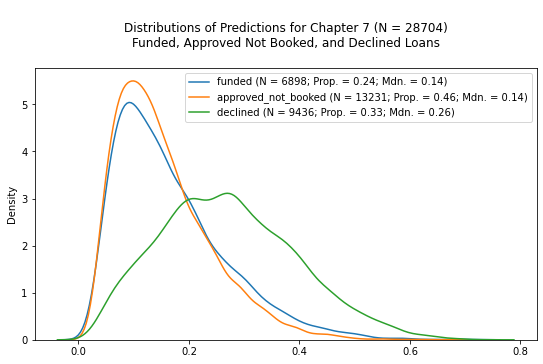

In [15]:
list_str_subset = [
    'funded',
    'approved_not_booked',
    'declined',
]
# ax
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Predictions for Chapter 7 (N = {df.shape[0]})
Funded, Approved Not Booked, and Declined Loans
"""
ax.set_title(str_title)
# iterate
for str_subset in list_str_subset:
    # subset
    df_tmp = df[df[str_subset] == 1].copy()
    # get list of predictions
    list_yhat = list(df_tmp['y_hat_ad'])
    int_len_yhat = len(list_yhat)
    flt_prop = int_len_yhat / df.shape[0]
    flt_mdn = np.median(list_yhat)
    # plot
    str_label = f'{str_subset} (N = {int_len_yhat}; Prop. = {flt_prop:0.2f}; Mdn. = {flt_mdn:0.2f})'
    sns.kdeplot(list_yhat, ax=ax, label=str_label)

# legend
plt.legend()
# show
plt.show()

### Compare medians of predictions

In [16]:
list_str_subset = [
    'funded',
    'approved_not_booked',
    'declined',
]
list_dict_row = []
for str_subset in list_str_subset:
    # subset
    df_tmp = df[df[str_subset] == 1].copy()
    # get mdn
    flt_mdn = df_tmp['y_hat_ad'].median()
    # dict row
    dict_row = {
        'str_subset': str_subset,
        'flt_mdn': flt_mdn,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)
# show
df_tmp

,str_subset,flt_mdn
0,funded,0.144364
1,approved_not_booked,0.135432
2,declined,0.263460


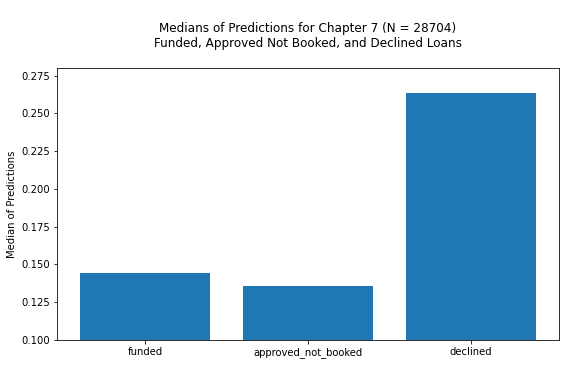

In [17]:
# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Medians of Predictions for Chapter 7 (N = {df.shape[0]})
Funded, Approved Not Booked, and Declined Loans
"""
ax.set_title(str_title)
ax.set_ylabel('Median of Predictions')
ax.bar(df_tmp['str_subset'], df_tmp['flt_mdn'])

# set ylim
ax.set_ylim(0.10, 0.28)

# show
plt.show()

### Compare means of actuals

In [18]:
list_str_subset = [
    'funded',
    'approved_not_booked',
    'declined',
]
list_dict_row = []
for str_subset in list_str_subset:
    # subset
    df_tmp = df[df[str_subset] == 1].copy()
    # get mean
    flt_mean = df_tmp['y_hat_ad'].mean()
    # dict row
    dict_row = {
        'str_subset': str_subset,
        'flt_mean': flt_mean,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)
# show
df_tmp

,str_subset,flt_mean
0,funded,0.167111
1,approved_not_booked,0.153383
2,declined,0.271204


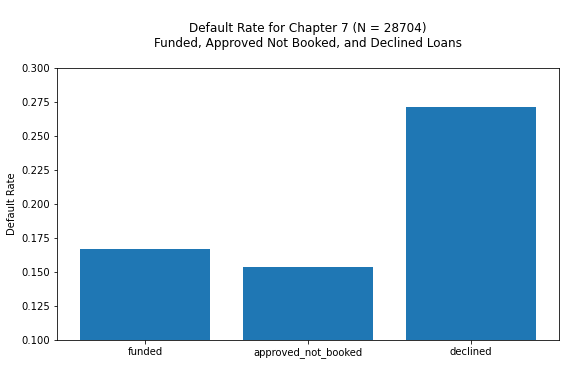

In [19]:
# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Default Rate for Chapter 7 (N = {df.shape[0]})
Funded, Approved Not Booked, and Declined Loans
"""
ax.set_title(str_title)
ax.set_ylabel('Default Rate')
ax.bar(df_tmp['str_subset'], df_tmp['flt_mean'])

# set ylim
ax.set_ylim(0.10, 0.30)

# show
plt.show()

### Get performance for every subset

In [20]:
list_str_subset = [
    'funded',
    'approved_not_booked',
    'declined',
]
list_dict_row = []
for str_subset in list_str_subset:
    # subset
    df_tmp = df[df[str_subset] == 1].copy()
    # get score
    flt_score = roc_auc_score(
        y_true=df_tmp['target'], 
        y_score=df_tmp['y_hat_ad'],
    )
    # dict row
    dict_row = {
        'str_subset': str_subset,
        'flt_score': flt_score,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)
# show
df_tmp

,str_subset,flt_score
0,funded,0.727621
1,approved_not_booked,0.715860
2,declined,0.691545


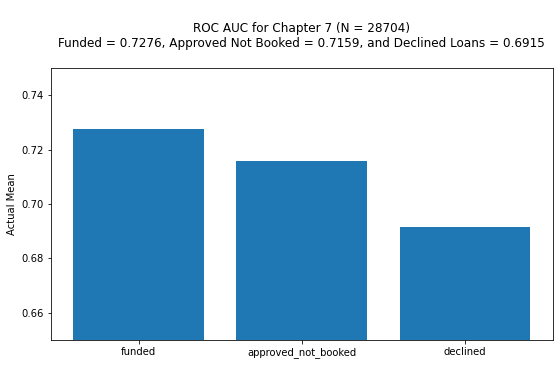

In [21]:
# plot
dict_score = dict(zip(df_tmp['str_subset'], df_tmp['flt_score']))
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
ROC AUC for Chapter 7 (N = {df.shape[0]})
Funded = {dict_score['funded']:0.4f}, Approved Not Booked = {dict_score['approved_not_booked']:0.4f}, and Declined Loans = {dict_score['declined']:0.4f}
"""
ax.set_title(str_title)
ax.set_ylabel('Actual Mean')
ax.bar(df_tmp['str_subset'], df_tmp['flt_score'])

# set ylim
ax.set_ylim(0.65, 0.75)

# show
plt.show()